# Variable Time Shifts

This notebook contains an example of performing a variable time shift.

In [93]:
import numpy as np
import matplotlib.pyplot as plt
import time 

import WDM
from WDM.code.plotting.plotting import time_frequency_plot
from WDM.code.discrete_wavelet_transform import WDM 

Small helper function to compare signals

In [94]:
def calc_mismatch(h1, h2):
    """
    Computes the mismatch between signals h1 and h2. 
    """
    inner_product = np.abs(np.dot(h1, h2))
    norm_h1 = np.sqrt(np.dot(h1,h1))
    norm_h2 = np.sqrt(np.dot(h2,h2))

    overlap = inner_product / (norm_h1 * norm_h2)
    mismatch = 1 - overlap

    return mismatch

Let's start by creating an example signal. We will use a simple sine-Gaussian.

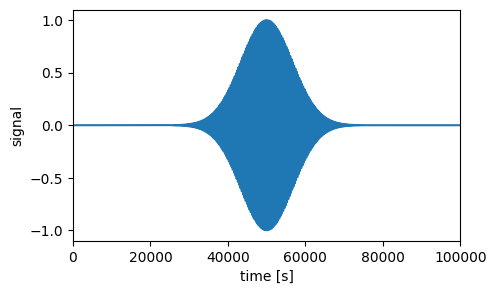

In [95]:
fs = 0.2    # sampling frequency [Hz]
T  = 1.0e5  # duration [s]
f0 = 3.0e-3 # central frequency [Hz]
w  = T/15.  # duration [s]

sine_gauss = lambda t: np.exp(-0.5*((t-T/2.)/w)**2)*np.sin(2*np.pi*f0*t)

times = np.arange(0, T, 1/fs)
signal = sine_gauss(times)

fig, ax = plt.subplots(figsize=(5,3))
ax.plot(times, signal)
ax.set_xlim(0, T)
ax.set_xlabel(r'time [s]')
ax.set_ylabel('signal')
plt.show()

Now we set up the WDM transform object. We use 200 frequency slices.

In [96]:
N, Nf= times.shape[0], 200

wdm = WDM.WDM_transform(dt=1/fs, Nf=Nf, N=N, q=32, calc_m0=True)

print(wdm)

WDM_transform(Nf=200, N=20000, q=32, d=4, A_frac=0.25, calc_m0=True)
self.Nt = 100 time cells
self.Nf = 200 frequency cells
self.dT = 1000.0 time resolution
self.dF = 0.0005 frequency resolution
self.dt = 5.0 time series cadence
self.df = 1e-05 time series fft frequency resolution
self.K = 12800 window length


Now take the discrete wavelet transform of our signal.

In [97]:
w = wdm(signal)

Just to check that everything is working, let's plot the time-frequency coefficients.

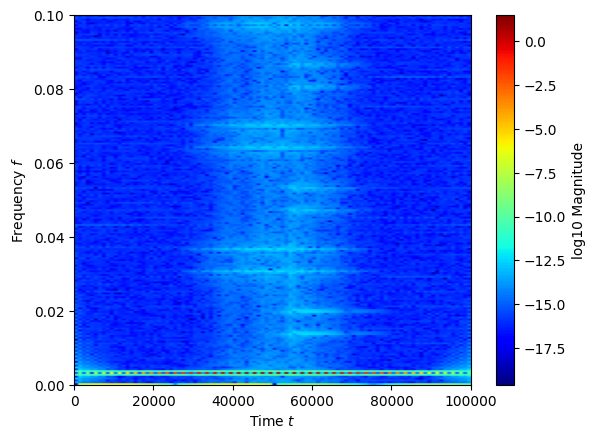

In [100]:
fig, ax = time_frequency_plot(wdm, w, scale='log')
plt.show()

In order to use the time-delay filters to peform time shifts using the `WDM` package it is first necessary to call the `build_time_delay_filter_interpolants` method. The arguments are the maximum lag index `L` and the number of interpolation points `N`.

In [9]:
L = 25  # the maximum lag index
N = 10  # the number of interpolation points
wdm.build_time_delay_filter_interpolants(L, N)

tn = np.arange(wdm.Nt)*wdm.dT

First, let's consider the case of a constant time shift $\delta$.

In [10]:
delta_constant = lambda t: (T/10.)*np.ones_like(t)

We will now apply this time shift to the signal using two methods.
First, as a check, we do this simply in the time domain by interpoating the original signal.
Second, using the `WDM` package, we apply the shift in the time-frequency domain using the time-delay filters.

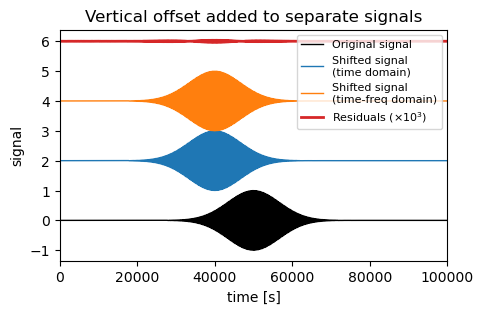

The mismatch between the methods is: 3.1635660757700634e-10


In [11]:
shifted_signal_constant_t = np.interp(times + delta_constant(times), 
                                      times, 
                                      signal)

w_shifted_constant = wdm.apply_variable_time_shift(w, delta_constant(tn))
shifted_signal_constant_tf = wdm.idwt(w_shifted_constant)

fig, ax = plt.subplots(figsize=(5,3))
ax.plot(times, signal, 
        c='k', lw=1, label='Original signal')
ax.plot(times, 2+shifted_signal_constant_t, 
        c='C0', lw=1, label='Shifted signal\n(time domain)')
ax.plot(times, 4+shifted_signal_constant_tf, 
        c='C1', lw=1, label='Shifted signal\n(time-freq domain)')
ax.plot(times, 6+1000*(shifted_signal_constant_t-shifted_signal_constant_tf), 
        c='C3', lw=2, label=r'Residuals ($\times 10^3$)')
ax.set_xlim(0, T)
ax.set_xlabel(r'time [s]')
ax.set_ylabel('signal')
ax.legend(fontsize=8, loc='upper right')
ax.set_title('Vertical offset added to separate signals')
plt.show()

print("The mismatch between the methods is:", calc_mismatch(shifted_signal_constant_t, shifted_signal_constant_tf))

Second, let's consider the case of a variable time shift $\delta(t)$ of the form $a + bt$.

In [12]:
delta_variable = lambda t,a,b: a+b*t

We now apply this variable time shift using the same two methods as before.

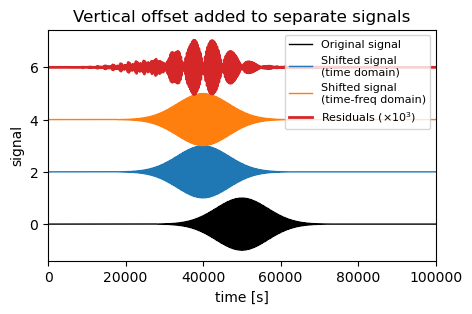

The mismatch between the methods is: 6.748666370182121e-08


In [14]:
starting_shift = T/10.
gradient = 1/1000.

shifted_signal_variable_t = np.interp(times + delta_variable(times, starting_shift, gradient), 
                                      times, 
                                      signal)

w_shifted_variable = wdm.apply_variable_time_shift(w, delta_variable(tn, starting_shift, gradient))
shifted_signal_variable_tf = wdm.idwt(w_shifted_variable)

fig, ax = plt.subplots(figsize=(5,3))
ax.plot(times, signal, 
        c='k', lw=1, label='Original signal')
ax.plot(times, 2+shifted_signal_variable_t, 
        c='C0', lw=1, label='Shifted signal\n(time domain)')
ax.plot(times, 4+shifted_signal_variable_tf, 
        c='C1', lw=1, label='Shifted signal\n(time-freq domain)')
ax.plot(times, 6+1000*(shifted_signal_variable_t-shifted_signal_variable_tf), 
        c='C3', lw=2, label=r'Residuals ($\times 10^3$)')
ax.set_xlim(0, T)
ax.set_xlabel(r'time [s]')
ax.set_ylabel('signal')
ax.legend(fontsize=8, loc='upper right')
ax.set_title('Vertical offset added to separate signals')
plt.show()

print("The mismatch between the methods is:", calc_mismatch(shifted_signal_variable_t, shifted_signal_variable_tf))

The accuracy of the variable time-shift depends on the evolution of the time shift arguments

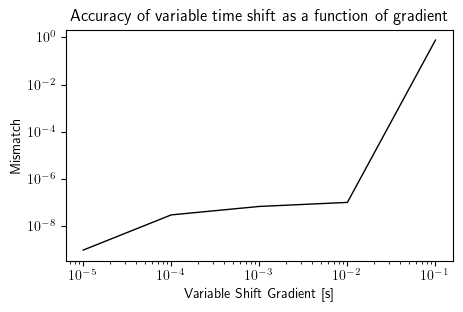

In [19]:
grad_list = [0.1, 0.01, 0.001, 0.0001, 0.00001]
mismatch_list = np.zeros_like(grad_list)
starting_shift = T/10.

for i in range(len(grad_list)):

    grad = grad_list[i]

    shifted_signal_variable_t = np.interp(times + delta_variable(times, starting_shift, grad), 
                                      times, 
                                      signal)

    w_shifted_variable = wdm.apply_variable_time_shift(w, delta_variable(tn, starting_shift, grad))
    shifted_signal_variable_tf = wdm.idwt(w_shifted_variable)   

    mismatch_list[i] = calc_mismatch(shifted_signal_variable_t, shifted_signal_variable_tf)

fig, ax = plt.subplots(figsize=(5,3))
ax.loglog(grad_list, mismatch_list, 
        c='k', lw=1,)

ax.set_xlabel(r'Variable Shift Gradient [s]')
ax.set_ylabel(r'Mismatch')
ax.set_title('Accuracy of variable time shift as a function of gradient')
plt.show()

It is important that the input signal is appropriately padded and modified before the application of the variable time shift. (See the diagram in the documentation for the time-delay filters).

Case 1: Signal in m = 0 bin

Consider a wavelet with a frequency that puts the signal in the m = 0 bin.

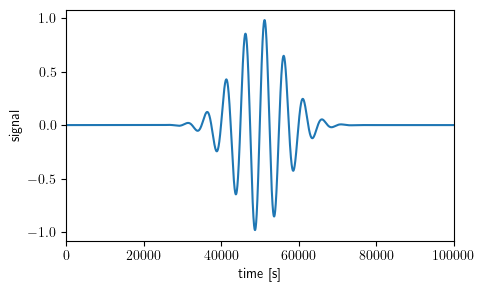

In [23]:
fs = 0.2    # sampling frequency [Hz]
T  = 1.0e5  # duration [s]
f0_m0 = 2.0e-4 # central frequency [Hz]
w  = T/15.  # duration [s]

sine_gauss = lambda t: np.exp(-0.5*((t-T/2.)/w)**2)*np.sin(2*np.pi*f0_m0*t)

times = np.arange(0, T, 1/fs)
signal_m0_bin = sine_gauss(times)

fig, ax = plt.subplots(figsize=(5,3))
ax.plot(times, signal_m0_bin)
ax.set_xlim(0, T)
ax.set_xlabel(r'time [s]')
ax.set_ylabel('signal')
plt.show()

As can be seen, this signal has support in the lowest bin

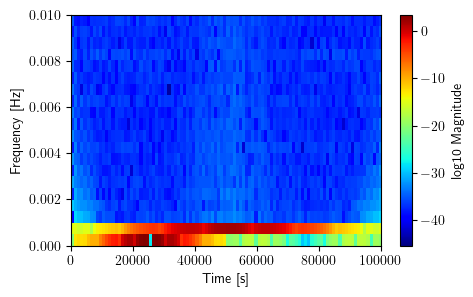

In [25]:
w_m0 = wdm(signal_m0_bin)

fig, ax = plt.subplots(figsize=(5,3))
im = ax.imshow(np.log(np.abs(w_m0.T)),
          aspect='auto', origin='lower', cmap='jet',
          extent=[0., wdm.T, 0., wdm.f_Ny])
fig.colorbar(im, label='log10 Magnitude', ax=ax)
ax.set_xlabel(r'Time [s]')
ax.set_ylabel(r'Frequency [Hz]')
ax.set_ylim(0,0.01)
plt.show()

Now if we apply the two variable time shifts to this system, we will observe a significant mismatch

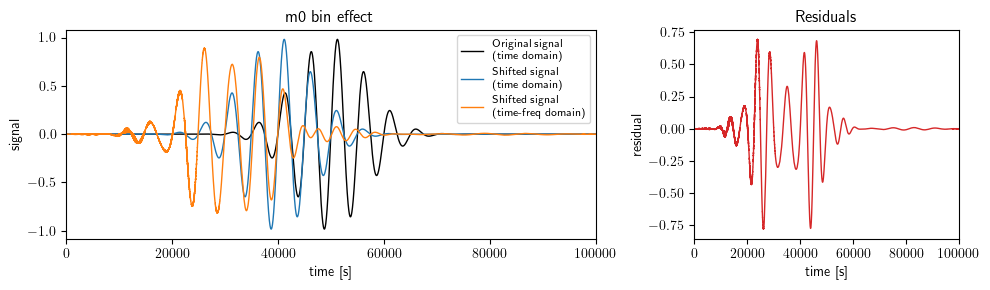

The mismatch between the methods is: 0.37937199095390683


In [31]:
starting_shift = T/10.
gradient = 1/1000.

shifted_signal_m0_variable_t = np.interp(times + delta_variable(times, starting_shift, gradient), 
                                      times, 
                                      signal_m0_bin)

w_m0_shifted_variable = wdm.apply_variable_time_shift(w_m0, delta_variable(tn, starting_shift, gradient))
shifted_m0_signal_variable_tf = wdm.idwt(w_m0_shifted_variable)

fig, (ax1, ax2) = plt.subplots(
    1, 2, figsize=(10, 3),
    gridspec_kw={'width_ratios': [2, 1]}
)

# Signals
ax1.plot(times, signal_m0_bin, 
         c='k', lw=1, label='Original signal\n(time domain)')
ax1.plot(times, shifted_signal_m0_variable_t, 
         c='C0', lw=1, label='Shifted signal\n(time domain)')
ax1.plot(times, shifted_m0_signal_variable_tf, 
         c='C1', lw=1, label='Shifted signal\n(time-freq domain)')

ax1.set_xlim(0, T)
ax1.set_xlabel(r'time [s]')
ax1.set_ylabel('signal')
ax1.legend(fontsize=8, loc='upper right')
ax1.set_title('m0 bin effect')

# Residuals
ax2.plot(
    times,
    shifted_signal_m0_variable_t - shifted_m0_signal_variable_tf,
    c='C3', lw=1
)

ax2.set_xlim(0, T)
ax2.set_xlabel(r'time [s]')
ax2.set_ylabel('residual')
ax2.set_title('Residuals')

plt.tight_layout()
plt.show()

print("The mismatch between the methods is:", calc_mismatch(shifted_signal_m0_variable_t, shifted_m0_signal_variable_tf))

Case 2: Signal too close to boundary

The time shift operator performs a cyclic shift on indices by different lag values, hence the signal needs to be appropriately zero-padded to avoid issues with overlapping regions. 


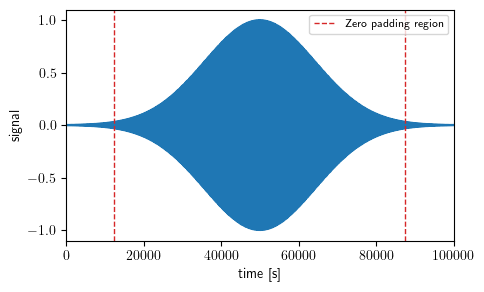

In [36]:
fs = 0.2    # sampling frequency [Hz]
T  = 1.0e5  # duration [s]
f0 = 3.0e-3 # central frequency [Hz]

w_wide = T/7.
sine_gauss = lambda t: np.exp(-0.5*((t-T/2.)/w_wide)**2) * np.sin(2*np.pi*f0*t)

times = np.arange(0, T, 1/fs)
signal_wide = sine_gauss(times)

fig, ax = plt.subplots(figsize=(5,3))

ax.plot(times, signal_wide)

padding_edge = 0.5 * L * wdm.dT

ax.axvline(
    padding_edge,
    ls='--',
    lw=1,
    c='C3',
    label='Zero padding region'
)

ax.axvline(
    T - padding_edge,
    ls='--',
    lw=1,
    c='C3'
)

ax.set_xlim(0, T)
ax.set_xlabel(r'time [s]')
ax.set_ylabel('signal')
ax.legend(fontsize=8)

plt.show()

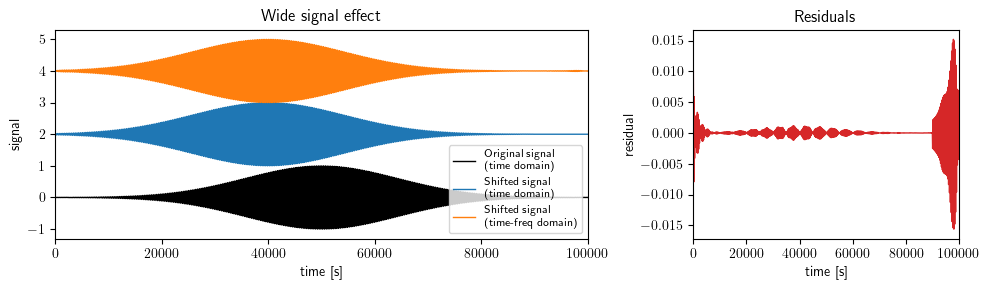

The mismatch between the methods is: 1.4562770826231919e-05


In [39]:
w_wide = wdm(signal_wide)

starting_shift = T/10.
gradient = 1/1000.

shifted_signal_wide_variable_t = np.interp(times + delta_variable(times, starting_shift, gradient), 
                                      times, 
                                      signal_wide)

w_wide_shifted_variable = wdm.apply_variable_time_shift(w_wide, delta_variable(tn, starting_shift, gradient))
shifted_wide_signal_variable_tf = wdm.idwt(w_wide_shifted_variable)

fig, (ax1, ax2) = plt.subplots(
    1, 2, figsize=(10, 3),
    gridspec_kw={'width_ratios': [2, 1]}
)

# Signals
ax1.plot(times, signal_wide, 
         c='k', lw=1, label='Original signal\n(time domain)')
ax1.plot(times, 2+shifted_signal_wide_variable_t, 
         c='C0', lw=1, label='Shifted signal\n(time domain)')
ax1.plot(times, 4+shifted_wide_signal_variable_tf, 
         c='C1', lw=1, label='Shifted signal\n(time-freq domain)')

ax1.set_xlim(0, T)
ax1.set_xlabel(r'time [s]')
ax1.set_ylabel('signal')
ax1.legend(fontsize=8, loc='lower right')
ax1.set_title('Wide signal effect')

# Residuals
ax2.plot(
    times,
    shifted_signal_wide_variable_t - shifted_wide_signal_variable_tf,
    c='C3', lw=1
)

ax2.set_xlim(0, T)
ax2.set_xlabel(r'time [s]')
ax2.set_ylabel('residual')
ax2.set_title('Residuals')

plt.tight_layout()
plt.show()

print("The mismatch between the methods is:", calc_mismatch(shifted_signal_wide_variable_t, shifted_wide_signal_variable_tf))
